#### Predict the House Price based on the Following factors:---

(a.)   Area

(b.)   Bedrooms

(c.)   Bathrooms

(d.)   stories


Perform the operation based on the Multiple Linear Regression:-------

#### Step 1 : Import all the necessary libraries

In [760]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection   import  train_test_split
from    sklearn.preprocessing     import  StandardScaler
from    sklearn.linear_model      import  LinearRegression
from    sklearn.metrics           import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#### Step 2:    Load the Dataset

In [761]:
df = pd.read_csv('Housing.csv')

In [762]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


#### OBSERVATIONS:

1.  The above dataset depicts about the House Price where it has multiple input features starting from

    area ...... till furnishingstatus as the input features

2.  This dataset has one output feature of price as the House Price.

3. The above dataset can be used for solving Multiple Linear Regression problem statement as it involves multiple input features starting from area .... furnishingstatus.

#### Step 3:    Perform the Data Exploration

In [763]:
#### Total length of the dataset

print("Total length of the dataset is:", len(df))

Total length of the dataset is: 545


In [764]:
#### Shape of the dataset 

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (545, 13)


In [765]:
#### Get all the columns from the dataset

print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [766]:
#### Get the information about the columns used in the dataset

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [767]:
#### Get the statistical description about all the columns used in the dataset

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


#### Step 4:    Perform the Data Cleaning

In [768]:
#### To check for all the NULL Values used in the dataset

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL Values in the dataset.

In [769]:
#### To check for any duplicate records in the dataset

df[df.duplicated()]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus


#### OBSERVATIONS:  

1.  There are no duplicate records used in the dataset.

In [770]:
#### Convert all the categorical columns into the numerical calues

df['mainroad'] = df['mainroad'].map({'yes' : 1, 'no' : 0})
df['guestroom'] = df['guestroom'].map({'yes' : 1, 'no' : 0})
df['basement'] = df['basement'].map({'yes' : 1, 'no' : 0})
df['hotwaterheating'] = df['hotwaterheating'].map({'yes' : 1, 'no' : 0})
df['airconditioning'] = df['airconditioning'].map({'yes' : 1, 'no' : 0})
df['prefarea'] = df['prefarea'].map({'yes' : 1, 'no' : 0})

In [771]:
#### Perform the Label Encoding on the furnishingstatus as it contains thre categories

from sklearn.preprocessing import LabelEncoder

lab = LabelEncoder()


df['furnishingstatus'] = lab.fit_transform(df['furnishingstatus'])


In [772]:
### Again get the entire dataset

df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,2
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,2
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0


#### OBSERVATIONS:

1. After applying mapping and label encoding , all the categorical columns have been converted into the numerical values.

<Axes: >

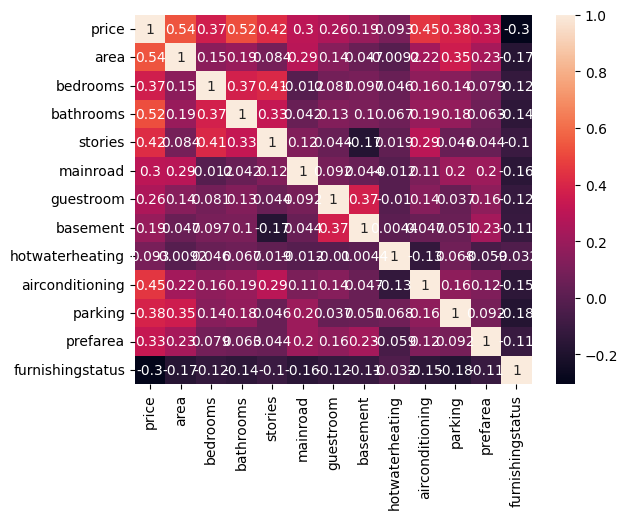

In [773]:
sns.heatmap(df.corr(), annot=True)

#### OBSERVATIONS:

1.  The above graph depicts about the correlation between the various numerical features used in the dataset.

#### Step 5: Divide the dataset into independent and dependent variables

In [774]:

#### Independent features

X = df[['area','bedrooms','bathrooms','stories']]

In [775]:
X

,area,bedrooms,bathrooms,stories
0,7420,4,2,3
1,8960,4,4,4
2,9960,3,2,2
3,7500,4,2,2
4,7420,4,1,2
...,...,...,...,...
540,3000,2,1,1
541,2400,3,1,1
542,3620,2,1,1
543,2910,3,1,1


In [776]:
#### Dependent feature

Y = df['price']

In [777]:
Y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

#### OBSERVATIONS:

1.  The dataset has been divided into the independent and dependent features.

    Independent features contains area, bedrooms, bathrooms, stories

    Dependent   features contains price.

#### Step 6: Divide the independent and dependent features into the training and testing data

In [778]:
from  sklearn.model_selection  import  train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [779]:
X_train

,area,bedrooms,bathrooms,stories
46,6000,3,2,4
93,7200,3,2,1
335,3816,2,1,1
412,2610,3,1,2
471,3750,3,1,2
...,...,...,...,...
71,6000,4,2,4
106,5450,4,2,1
270,4500,3,2,3
435,4040,2,1,1


In [780]:
X_test

,area,bedrooms,bathrooms,stories
316,5900,4,2,2
77,6500,3,2,3
360,4040,2,1,1
90,5000,3,1,2
493,3960,3,1,1
...,...,...,...,...
15,6000,4,1,2
357,6930,4,1,2
39,6000,4,2,4
54,6000,3,2,2


In [781]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing data is:", X_test.shape)

Shape of the input training data is: (436, 4)
Shape of the input testing data is: (109, 4)


In [782]:
Y_train

46     7525000
93     6300000
335    3920000
412    3430000
471    3010000
        ...   
71     6755000
106    6160000
270    4340000
435    3290000
102    6195000
Name: price, Length: 436, dtype: int64

In [783]:
Y_test

316    4060000
77     6650000
360    3710000
90     6440000
493    2800000
        ...   
15     9100000
357    3773000
39     7910000
54     7350000
155    5530000
Name: price, Length: 109, dtype: int64

In [784]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing data is:",  Y_test.shape)

Shape of the output training data is: (436,)
Shape of the output testing data is: (109,)


#### OBSERVATIONS:

1.  The dataset is divided into the training data and the testing data

2.  Training data is 80 % of the records

3.  Testing data  has 20 % of the records.

#### Step 7: Perform the Feature Scaling

In [785]:
from sklearn.preprocessing import StandardScaler

#### Craete an object for Standard Scaler

sc = StandardScaler()

#### usig the object for Standard Scaler, scale the inputs

X_train_scaled = sc.fit_transform(X_train)

In [786]:
X_test_scaled = sc.transform(X_test)

In [787]:
X_train_scaled

array([[ 0.38416819,  0.05527092,  1.53917323,  2.58764353],
       [ 0.9291807 ,  0.05527092,  1.53917323, -0.91249891],
       [-0.60775457, -1.28351359, -0.5579503 , -0.91249891],
       ...,
       [-0.29709744,  0.05527092,  1.53917323,  1.42092939],
       [-0.5060189 , -1.28351359, -0.5579503 , -0.91249891],
       [ 0.15707965,  0.05527092,  1.53917323,  2.58764353]],
      shape=(436, 4))

In [788]:
X_test_scaled

array([[ 0.33875048,  1.39405543,  1.53917323,  0.25421524],
       [ 0.61125674,  0.05527092,  1.53917323,  1.42092939],
       [-0.5060189 , -1.28351359, -0.5579503 , -0.91249891],
       [-0.0700089 ,  0.05527092, -0.5579503 ,  0.25421524],
       [-0.54235307,  0.05527092, -0.5579503 , -0.91249891],
       [ 0.7111757 ,  0.05527092, -0.5579503 , -0.91249891],
       [ 1.52869446,  0.05527092, -0.5579503 , -0.91249891],
       [-0.07455067,  1.39405543,  1.53917323,  0.25421524],
       [-0.86936058, -1.28351359, -0.5579503 , -0.91249891],
       [-1.11461621,  0.05527092, -0.5579503 , -0.91249891],
       [ 1.55594508,  1.39405543,  3.63629675,  2.58764353],
       [-0.55416168, -1.28351359, -0.5579503 , -0.91249891],
       [-0.65135557, -1.28351359, -0.5579503 , -0.91249891],
       [-0.93294537,  0.05527092, -0.5579503 ,  0.25421524],
       [-0.5378113 ,  0.05527092, -0.5579503 ,  0.25421524],
       [-0.69223151,  0.05527092,  3.63629675,  0.25421524],
       [-1.43254017, -1.

#### OBSERVATIONS:

1.  After performing the feature scaling on the inputs, all the inputs are now in the same scale range.

#### Step 8: Train the Linear Regression Model

In [789]:
from sklearn.linear_model import LinearRegression

#### Craete the object for Linear Regression

lin = LinearRegression()

#### using the object for Linear Regression, train the model

lin.fit(X_train_scaled, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### OBSERVATIONS:

1.  The linear regression model has been trained with the help of the training data.

#### Step 9: Predict the Model

In [790]:
Y_pred = lin.predict(X_test_scaled)

print(Y_pred)

[6177576.81007289 6696157.1747214  3437037.80871784 4430631.95405246
 3583802.16724906 4547069.04340544 5175286.57133352 5859977.94873147
 3157830.01852758 3144049.89769941 9338793.18082852 3400042.77651763
 3325354.69264173 3767513.4523506  4071151.92418251 6468790.52236393
 3208917.60328875 4779641.69179028 4727290.23112961 4121096.89468396
 5405331.46791935 4583715.06586791 3300575.00126235 4011820.26876708
 5081053.94214431 7419871.20773819 3105478.55786691 4990763.43308296
 7292511.80350258 3557927.34102657 5339773.17082078 3774493.64710536
 6521652.30585249 4994282.68049904 4526789.9006117  5549179.01346347
 4307082.50689327 3970119.36891988 3416277.49313491 5091109.49649506
 4986821.3129551  3293943.81624533 6668236.39570237 4151424.16386221
 4382854.19798733 4080960.77484411 7005511.96540856 4479673.5860171
 4836566.85704649 3074067.6814705  7520301.32857184 3074067.6814705
 4738844.1304799  4256127.08518355 4130663.84827928 3217341.94262435
 6918259.5309741  3523206.63593413 5

#### Step 10: Compute the Model Coefficients:

In [791]:
print("Slope     of the model is:", lin.coef_[0])
print("Intercept of the model is:", lin.intercept_)

Slope     of the model is: 768444.1717636569
Intercept of the model is: 4706527.385321101


#### Step 11: Evaluate the Regression Metrics:

In [792]:
from sklearn.metrics  import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

mae = mean_absolute_error(Y_test, Y_pred)

print("Mean Absolute Error of the model is:", mae)

Mean Absolute Error of the model is: 1158970.480316688


In [793]:
mse = mean_squared_error(Y_test, Y_pred)

print("Mean Squared Error of the model is:", mse)

Mean Squared Error of the model is: 2457741642022.0894


In [794]:
rmse = root_mean_squared_error(Y_test, Y_pred)

print("Root Mean Squared Error of the model is:", rmse)

Root Mean Squared Error of the model is: 1567718.6106001579


In [795]:
r2 = r2_score(Y_test, Y_pred)

print("R2 Score of the model is:", r2)

R2 Score of the model is: 0.5137585349037066


#### OBSERVATIONS:

1.  The R2 Score of the model is0.5137 which is ok. So the Model is fine.

#### Step 12: Dump the model

In [796]:
import joblib

joblib.dump(sc , "Standard.pkl")
joblib.dump(lin,"multiple_linear.pkl")

['multiple_linear.pkl']